# Plots to differentiate models

Conda environment for this notebook

´´´
conda env create
´´´

## Plots of training sequences


MNIST_HGQ_DynamicTraining_log
merk at accuracy kollapser rundt epoch 4250

In [86]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import numpy as np
%matplotlib inline

In [87]:
nrows, ncols = 2, 3

colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]

config = [
    {"labelname": "MNIST CNN HGQ StaticTraining", "filepath": "../MNIST/MNIST_CNN_HGQ_StaticTraining/MNIST_HGQ_StaticTraining_log.csv"},
    {"labelname": "MNIST CNN HGQ DynamicTraining", "filepath": "../MNIST/MNIST_CNN_HGQ_DynamicTraining/MNIST_CNN_HGQ_DynamicTraining_log.csv"},
    {"labelname": "MNIST MLP HGQ StaticTraining", "filepath": "../MNIST/MNIST_MLP_HGQ_StaticTraining/MNIST_MLP_HGQ_StaticTraining_log.csv"},
    {"labelname": "MNIST MLP HQG DynamicTraining", "filepath": "../MNIST/MNIST_MLP_HGQ_DynamicTraining/MNIST_MLP_HQG_DynamicTraining_log.csv"},
    {"labelname": "JET HGQ Training", "filepath": "../JET_HGQ_Training_log.csv"},
]

data = [
    {
        "labelname": line["labelname"],
        "dataframe": pd.read_csv(line['filepath'], sep=';', index_col=0),
    }
    for line in config
]

data[0]
#df = data[1]["dataframe"]
#df[:10]

{'labelname': 'MNIST CNN HGQ StaticTraining',
 'dataframe':        accuracy     ebops       loss  val_accuracy  val_loss
 epoch                                                       
 0      0.702833  32608422  33.566177      0.936833  0.226223
 1      0.921537  32608422  32.868439      0.968167  0.115436
 2      0.950981  32608422  32.774136      0.978333  0.081441
 3      0.960519  20039705  29.355640      0.981667  0.071372
 4      0.964519  20032106  20.157852      0.982833  0.063101
 ...         ...       ...        ...           ...       ...
 7995   0.876074     39861   0.432449      0.955000  0.158536
 7996   0.877222     41371   0.430965      0.955667  0.160368
 7997   0.878148     41072   0.428267      0.955000  0.157848
 7998   0.873056     39618   0.444453      0.942000  0.199207
 7999   0.870722     40927   0.455742      0.943833  0.178555
 
 [8000 rows x 5 columns]}

### Accuracy over Ebops

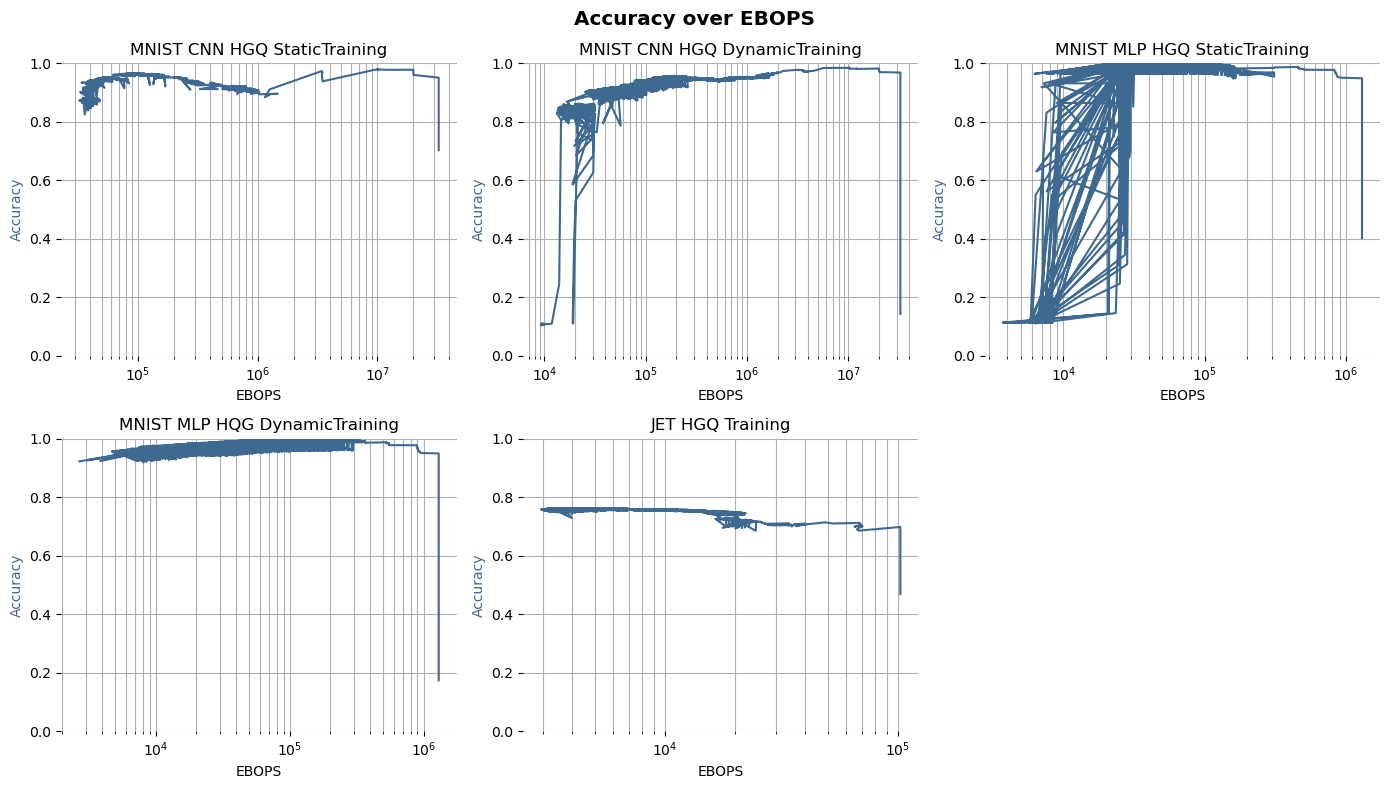

In [88]:
plotname = "Accuracy over EBOPS"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 8))
axs = axs.flatten()

for i, item in enumerate(data):
    #ax = axs[i // 3, i % 3] # flattened instead
    ax1 = axs[i]
    df = item['dataframe']

    #ax1.plot('ebops', 'accuracy', data=df, color=colors[0])
    ax1.semilogx('ebops', 'accuracy', data=df, color=colors[0])
    ax1.set_ylim(0, 1)
    ax1.grid(True, which='both')

    ax1.set_title(item['labelname'])
    ax1.set_xlabel('EBOPS')
    ax1.set_ylabel('Accuracy', color=colors[0])

    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["bottom"].set_visible(False)

    # Overflow
    if (i+1) >= len(data):
        axs[i+1].axis('off')


plt.suptitle(plotname, size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

Same graph, but plotted over each other for direct comparison. By selecting thresholds in EBOPS or accuracy, you may visualize which model may be the best fit.

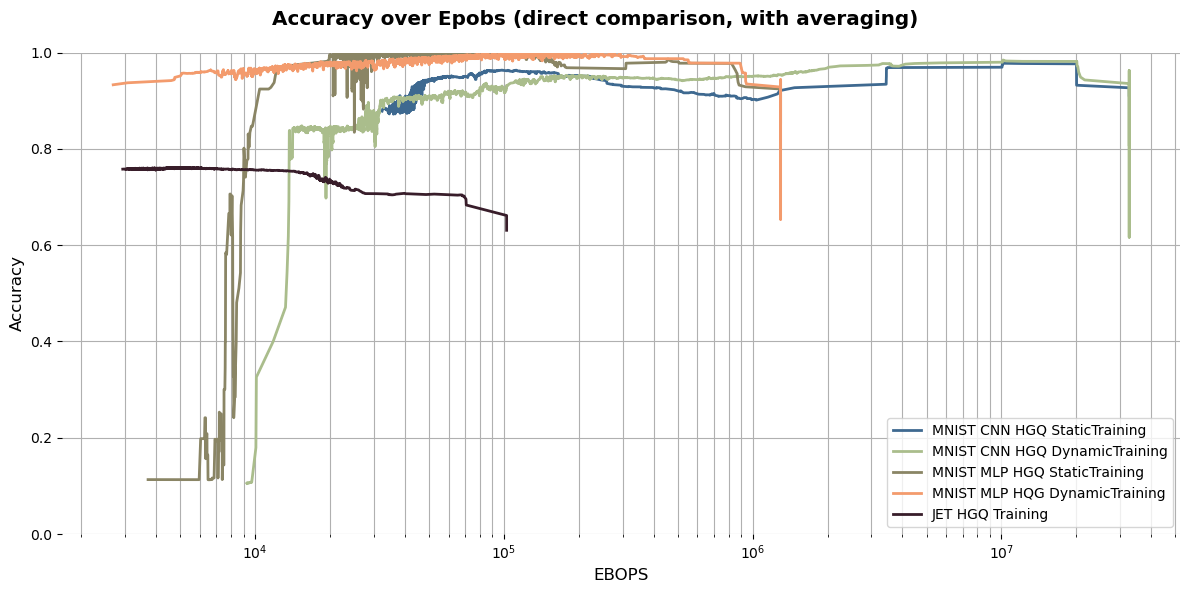

In [89]:
plotname = "Accuracy over Epobs (direct comparison, with averaging)"
fig, ax = plt.subplots(figsize=(12, 6))

# moving average filter / lavpassfilter for smoothing the colossal amount of data
window_size = 10

for i, item in enumerate(data):
    df = item['dataframe'].sort_values('ebops')
    df_smooth = df.copy()
    df_smooth['accuracy'] = df['accuracy'].rolling(window=window_size, center=True, min_periods=1).mean()
    ax.semilogx('ebops', 'accuracy', data=df_smooth, color=colors[i], label=item['labelname'], linewidth=2)

ax.set_ylim(0, 1)
ax.set_xlabel('EBOPS', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.grid(True, which='both')#, axis='x')
ax.legend(loc='best', fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.suptitle(plotname, size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

### Accuracy and EBOPS over Epochs (timeseries)

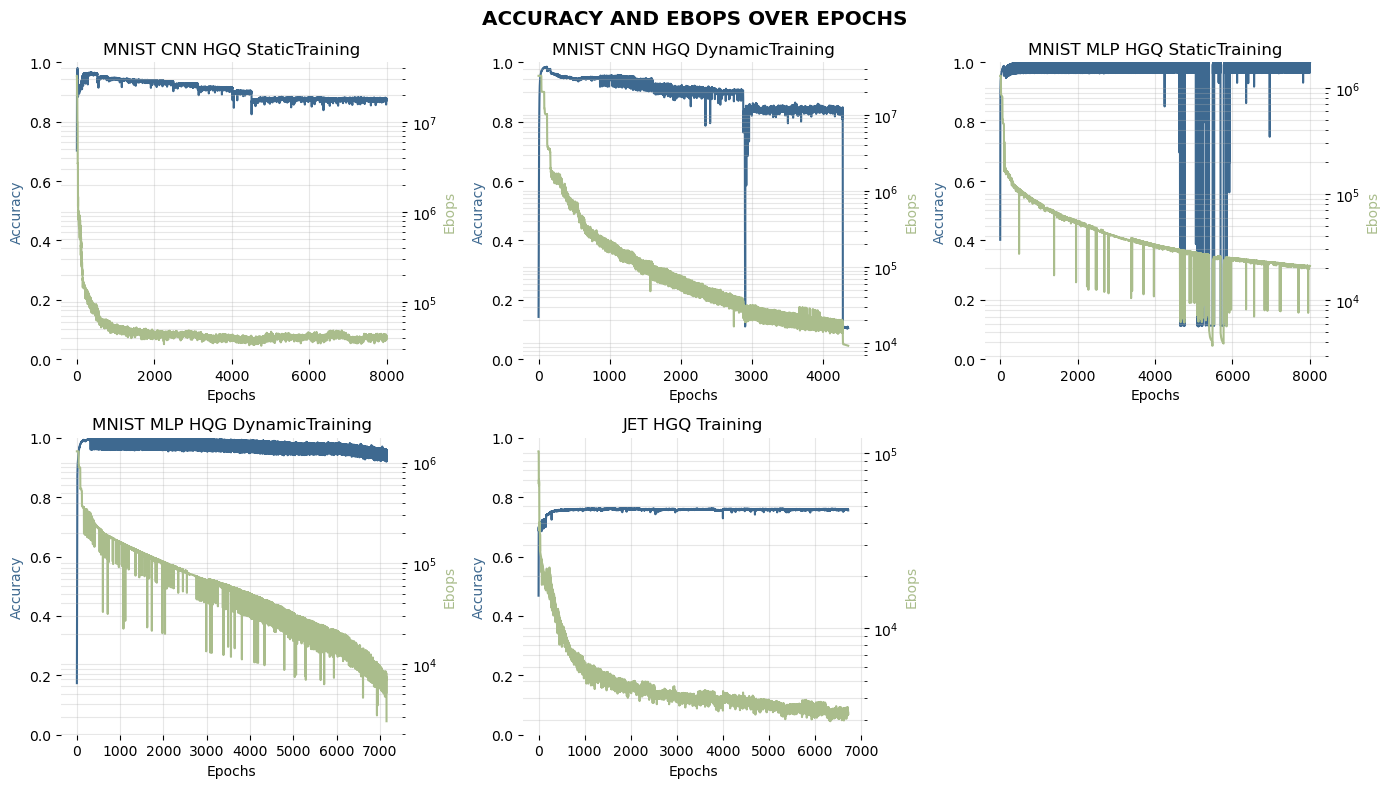

In [90]:
plotname = "Accuracy and Ebops over Epochs"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 8))
axs = axs.flatten()


for i, item in enumerate(data):
    ax1 = axs[i]
    ax2 = ax1.twinx()
    df = item['dataframe']


    ax1.plot(df.index, 'accuracy', data=df, color=colors[0])
    ax1.set_ylim(0, 1)

    ax2.set_ylabel('Ebops', color=colors[1])
    ax2.semilogy(df.index, 'ebops', data=df, color=colors[1])

    ax1.set_title(item['labelname'])
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy', color=colors[0])
    ax1.grid(True, which='both', alpha=0.3, axis='x')
    ax2.grid(True, which='both', alpha=0.3)

    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["bottom"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["bottom"].set_visible(False)
    #ax2.grid()
    # Overflow
    if (i+1) >= len(data):
        axs[i+1].axis('off')

    
plt.suptitle(plotname.upper(), size = 'x-large', weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")


# Annotations https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotate_transform.html
# Minimalistic https://practicaldatascience.org/notebooks/class_5/week_1/2.2.2_making_plots_pretty_2.html